# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 13 — Asset-Class Specialist Architecture

**Purpose:** test the simplest fixed specialist architecture suggested by the completed research, without introducing another performance-chasing meta-selector.

Notebooks 10–12 established three important findings:

1. **Dual Trend 13/52 remains the strongest broad multi-asset core.**
2. **SuperbCommand appears particularly competitive in equities.**
3. **Dynamic asset-class strategy selection underperformed badly out of sample.**

Notebook 13 therefore tests a deliberately parsimonious architecture:

> **Use a fixed signal family by asset class where the research suggests a persistent structural advantage, rather than repeatedly switching strategies through time.**

### Primary specialist hypothesis

The pre-declared primary architecture is:

- **Equities → SuperbCommand PT_REDUCE_25**
- **Commodities → Dual Trend 13/52**
- **FX → Dual Trend 13/52**
- **Rates → Dual Trend 13/52**
- **Crypto → Dual Trend 13/52**

Why `SC_PT_REDUCE_25` rather than `SC_CORE` for equities?

- Notebook 04 found the profit-taking reduction rule modestly improved risk-adjusted performance.
- Notebook 12's portfolio-level incremental attribution was explicitly based on the `PT_REDUCE_25` SuperbCommand sleeve.
- Using one already-tested SuperbCommand specification avoids creating a new post-hoc variant.

### Crypto sensitivity

Crypto remains the least settled asset class. Notebook 12 found:

- Dual Trend remained very strong;
- SuperbCommand was approximately competitive;
- the universe contains only one crypto market.

Therefore Notebook 13 tests only three **predefined crypto treatments**:

1. **Crypto = Dual Trend** — primary specification.
2. **Crypto = 50/50 SC_PT_REDUCE_25 / Dual Trend.**
3. **Crypto = SC_PT_REDUCE_25.**

No other asset class is re-optimised.

### Portfolio construction

Every architecture uses **hierarchical inverse-volatility weighting at the asset-class level**, estimated with trailing data only.

The specialist signal map is fixed through time; only risk weights evolve.

### Benchmarks

Compare against:

- Pure Dual Trend + hierarchical inverse vol
- Pure TSMOM + hierarchical inverse vol
- Passive + hierarchical inverse vol
- Portfolio-level WF Blend Selector

### Robustness / falsification

Notebook 13 includes:

- common-period performance;
- calendar-year results;
- rolling Sharpe;
- stress tests;
- leave-one-asset-class-out diagnostics;
- asset-class contribution decomposition;
- transaction-cost stress;
- moving-block bootstrap versus Dual Trend;
- subperiod stability;
- parsimony scorecard.

### Anti-overfitting rule

This notebook does **not** search across arbitrary strategy maps.

Only the single research-motivated specialist map and the three predeclared crypto treatments are tested.

### Final holdout

Research ends:

**31 December 2025**

The entire 2026 period remains untouched.


In [1]:
# ============================================================
# 13.1 — IMPORTS, DRIVE & PROJECT CONFIGURATION
# ============================================================
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}
RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 13 cannot run with the 2026 holdout unlocked.")

AC_PANEL_PATH = PATHS["data_processed"] / "10_asset_class_strategy_return_panel.parquet"
BASELINE_PATH = PATHS["data_processed"] / "06_baseline_return_panel.parquet"
WF_BLEND_PATH = PATHS["data_processed"] / "08_composite_walkforward_return.parquet"

for p in [AC_PANEL_PATH, BASELINE_PATH, WF_BLEND_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Required upstream file not found: {p}")

print("Project:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
2026 holdout: LOCKED


In [2]:
# ============================================================
# 13.2 — LOAD UPSTREAM DATA
# ============================================================
ac_panel = pd.read_parquet(AC_PANEL_PATH)
baseline_panel = pd.read_parquet(BASELINE_PATH)
wf_blend_df = pd.read_parquet(WF_BLEND_PATH)

for name, obj in [
    ("asset-class panel", ac_panel),
    ("baseline panel", baseline_panel),
    ("WF blend", wf_blend_df),
]:
    if obj.index.max() >= HOLDOUT_START:
        raise RuntimeError(f"Holdout contamination detected in {name}.")

asset_classes = sorted(ac_panel.columns.get_level_values("asset_class").unique())

EXPECTED_CLASSES = {"commodities", "crypto", "equities", "fx", "rates"}
if set(asset_classes) != EXPECTED_CLASSES:
    raise RuntimeError(
        f"Unexpected asset classes. Found {asset_classes}, expected {sorted(EXPECTED_CLASSES)}"
    )

print("Asset classes:", asset_classes)
display(ac_panel.tail())


Asset classes: ['commodities', 'crypto', 'equities', 'fx', 'rates']


asset_class commodities                                             \
strategy        SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52 TSMOM_52W   
date                                                                 
2025-11-28     0.029944        0.029944         0.029944  0.029944   
2025-12-05     0.003998        0.003998         0.003998  0.003998   
2025-12-12     0.002858        0.002858         0.002858  0.002858   
2025-12-19     0.003000        0.003000         0.003000  0.003000   
2025-12-26     0.035640        0.035640         0.035640  0.035640   

asset_class                 crypto                                             \
strategy    PASSIVE_LONG   SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52 TSMOM_52W   
date                                                                            
2025-11-28      0.029944  0.068498        0.068498              0.0       0.0   
2025-12-05      0.003998 -0.016845       -0.016845              0.0       0.0   
2025-12-12      0.002858  0.009874        0.009874              0.0       0.0   
2025-12-19      0.003000 -0.024006       -0.024006              0.0       0.0   
2025-12-26      0.035640 -0.009102       -0.009102              0.0       0.0   

asset_class               ...        fx                                   \
strategy    PASSIVE_LONG  ...   SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52   
date                      ...                                              
2025-11-28      0.068498  ... -0.006640       -0.006640        -0.003170   
2025-12-05     -0.016845  ... -0.004608       -0.004608        -0.002304   
2025-12-12      0.009874  ... -0.004630       -0.004630        -0.002315   
2025-12-19     -0.024006  ...  0.004293        0.004293         0.002147   
2025-12-26     -0.009102  ... -0.006374       -0.006374        -0.003187   

asset_class                            rates                                   \
strategy    TSMOM_52W PASSIVE_LONG   SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52   
date                                                                            
2025-11-28        0.0    -0.006340  0.003472        0.003299         0.003472   
2025-12-05        0.0    -0.004608 -0.007973       -0.007652        -0.007973   
2025-12-12        0.0    -0.004630 -0.003275       -0.003226        -0.001849   
2025-12-19        0.0     0.004293  0.003072        0.002520         0.002225   
2025-12-26        0.0    -0.006374  0.001403        0.001081         0.001007   

asset_class                         
strategy    TSMOM_52W PASSIVE_LONG  
date                                
2025-11-28   0.003472     0.003472  
2025-12-05  -0.007973    -0.007973  
2025-12-12  -0.000921    -0.003275  
2025-12-19   0.003072     0.003072  
2025-12-26   0.001403     0.001403  

[5 rows x 25 columns]

## 13.3 Performance functions


In [3]:
# ============================================================
# 13.3 — PERFORMANCE FUNCTIONS
# ============================================================
WEEKS_PER_YEAR = 52

def max_drawdown(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    eq = (1 + r).cumprod()
    return float((eq / eq.cummax() - 1).min())

def cagr(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = float((1 + r).prod())
    years = len(r) / WEEKS_PER_YEAR
    if wealth <= 0 or years <= 0:
        return np.nan
    return wealth ** (1 / years) - 1

def ann_vol(r):
    r = pd.Series(r).dropna()
    if len(r) < 2:
        return np.nan
    return float(r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sharpe(r):
    r = pd.Series(r).dropna()
    if len(r) < 2 or r.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sortino(r):
    r = pd.Series(r).dropna()
    d = r[r < 0]
    if len(d) < 2 or d.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / d.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def calmar(r):
    ca = cagr(r)
    md = max_drawdown(r)
    if pd.isna(ca) or pd.isna(md) or md == 0:
        return np.nan
    return float(ca / abs(md))

def metrics(r):
    r = pd.Series(r).dropna()
    return {
        "weeks": len(r),
        "cagr": cagr(r),
        "ann_vol": ann_vol(r),
        "sharpe": sharpe(r),
        "sortino": sortino(r),
        "max_drawdown": max_drawdown(r),
        "calmar": calmar(r),
        "best_week": r.max() if len(r) else np.nan,
        "worst_week": r.min() if len(r) else np.nan,
        "positive_week_rate": (r > 0).mean() if len(r) else np.nan,
    }


## 13.4 Define the fixed specialist architectures

No strategy map is fitted inside this notebook.

The primary map is fixed before performance comparison.


In [4]:
# ============================================================
# 13.4 — PREDECLARED SPECIALIST MAPS
# ============================================================
PRIMARY_MAP = {
    "commodities": "DUAL_TREND_13_52",
    "crypto": "DUAL_TREND_13_52",
    "equities": "SC_PT_REDUCE_25",
    "fx": "DUAL_TREND_13_52",
    "rates": "DUAL_TREND_13_52",
}

CRYPTO_50_50_MAP = PRIMARY_MAP.copy()
CRYPTO_SC_MAP = PRIMARY_MAP.copy()
CRYPTO_SC_MAP["crypto"] = "SC_PT_REDUCE_25"

ARCHITECTURES = {
    "SPECIALIST_CRYPTO_DUAL": {
        "map": PRIMARY_MAP,
        "crypto_blend": None,
    },
    "SPECIALIST_CRYPTO_50_50": {
        "map": CRYPTO_50_50_MAP,
        "crypto_blend": (0.50, 0.50),
    },
    "SPECIALIST_CRYPTO_SC": {
        "map": CRYPTO_SC_MAP,
        "crypto_blend": None,
    },
}

print("Primary fixed specialist map:")
display(pd.Series(PRIMARY_MAP, name="strategy").to_frame())


Primary fixed specialist map:


,strategy
commodities,DUAL_TREND_13_52
crypto,DUAL_TREND_13_52
equities,SC_PT_REDUCE_25
fx,DUAL_TREND_13_52
rates,DUAL_TREND_13_52


## 13.5 Build asset-class sleeve return panels

For the 50/50 crypto sensitivity:

\[
R_{crypto,t}
=
0.5 R_{SC,t}
+
0.5 R_{Dual,t}
\]

All other sleeves use their fixed strategy assignment.


In [5]:
# ============================================================
# 13.5 — BUILD FIXED SLEEVE RETURNS
# ============================================================
def build_specialist_sleeves(spec):
    data = {}

    for asset_class in asset_classes:
        strategy = spec["map"][asset_class]

        if asset_class == "crypto" and spec["crypto_blend"] is not None:
            w_sc, w_dual = spec["crypto_blend"]
            sc = ac_panel[(asset_class, "SC_PT_REDUCE_25")]
            dt = ac_panel[(asset_class, "DUAL_TREND_13_52")]
            data[asset_class] = w_sc * sc + w_dual * dt
        else:
            data[asset_class] = ac_panel[(asset_class, strategy)]

    return pd.DataFrame(data).sort_index()

sleeve_panels = {
    name: build_specialist_sleeves(spec)
    for name, spec in ARCHITECTURES.items()
}

for name, df in sleeve_panels.items():
    print(name, df.shape)


SPECIALIST_CRYPTO_DUAL (1095, 5)
SPECIALIST_CRYPTO_50_50 (1095, 5)
SPECIALIST_CRYPTO_SC (1095, 5)


## 13.6 Dynamic hierarchical inverse-vol weighting

The signal architecture is fixed, but asset-class risk weights evolve using only trailing information.

Primary risk-estimation window:

**26 weeks**

This matches the medium-frequency nature of the strategy and is not optimised here.

Weights are lagged by one week.

\[
w_{c,t}
\propto
\frac{1}{\hat{\sigma}_{c,t-1}}
\]


In [6]:
# ============================================================
# 13.6 — DYNAMIC INVERSE-VOL WEIGHTS
# ============================================================
VOL_LOOKBACK_WEEKS = 26

def dynamic_inverse_vol_weights(return_panel, lookback=VOL_LOOKBACK_WEEKS):
    rolling_vol = (
        return_panel
        .rolling(lookback, min_periods=lookback)
        .std(ddof=1)
        .shift(1)
        * np.sqrt(WEEKS_PER_YEAR)
    )

    inv = 1 / rolling_vol.replace(0, np.nan)
    weights = inv.div(inv.sum(axis=1), axis=0)

    return weights

specialist_weights = {}
specialist_returns = {}

for name, sleeves in sleeve_panels.items():
    w = dynamic_inverse_vol_weights(sleeves)
    r = (w * sleeves).sum(axis=1, min_count=1)

    specialist_weights[name] = w
    specialist_returns[name] = r.rename(name)

specialist_return_panel = pd.concat(specialist_returns, axis=1)

display(specialist_return_panel.tail())


,SPECIALIST_CRYPTO_DUAL,SPECIALIST_CRYPTO_50_50,SPECIALIST_CRYPTO_SC
date,,,
2025-11-28,0.005477,0.006552,0.007460
2025-12-05,-0.003470,-0.003742,-0.003961
2025-12-12,-0.001503,-0.001349,-0.001229
2025-12-19,0.002293,0.001914,0.001618
2025-12-26,0.004105,0.003971,0.003871


## 13.7 Load external benchmark portfolios

Use previously constructed benchmark return series rather than rebuilding them.


In [7]:
# ============================================================
# 13.7 — BENCHMARK SERIES
# ============================================================
BENCHMARK_KEYS = {
    "DUAL_TREND_INV_VOL": ("DUAL_TREND_13_52", "hier_inverse_vol"),
    "TSMOM_INV_VOL": ("TSMOM_52W", "hier_inverse_vol"),
    "PASSIVE_INV_VOL": ("PASSIVE_LONG", "hier_inverse_vol"),
}

benchmarks = {}

for name, key in BENCHMARK_KEYS.items():
    if key not in baseline_panel.columns:
        raise KeyError(f"Missing baseline benchmark: {key}")
    benchmarks[name] = baseline_panel[key]

benchmarks["PORTFOLIO_WF_BLEND"] = wf_blend_df.iloc[:, 0]

benchmark_panel = pd.concat(benchmarks, axis=1)

comparison_panel = pd.concat(
    [specialist_return_panel, benchmark_panel],
    axis=1
).dropna(how="any")

comparison_panel = comparison_panel.loc[:RESEARCH_END]

print("Common comparison sample:")
print(comparison_panel.index.min().date(), "→", comparison_panel.index.max().date())
print("Weeks:", len(comparison_panel))
display(comparison_panel.tail())


Common comparison sample:
2011-01-07 → 2025-12-26
Weeks: 782


,SPECIALIST_CRYPTO_DUAL,SPECIALIST_CRYPTO_50_50,SPECIALIST_CRYPTO_SC,DUAL_TREND_INV_VOL,TSMOM_INV_VOL,PASSIVE_INV_VOL,PORTFOLIO_WF_BLEND
date,,,,,,,
2025-11-28,0.005477,0.006552,0.007460,0.006927,0.008418,0.008463,0.007753
2025-12-05,-0.003470,-0.003742,-0.003961,-0.000803,-0.000097,-0.002017,-0.001729
2025-12-12,-0.001503,-0.001349,-0.001229,-0.001138,-0.000432,-0.001739,-0.001575
2025-12-19,0.002293,0.001914,0.001618,0.002110,0.001621,0.002079,0.001880
2025-12-26,0.004105,0.003971,0.003871,0.006115,0.007089,0.005026,0.005128


## 13.8 Common-period performance


In [8]:
# ============================================================
# 13.8 — PERFORMANCE COMPARISON
# ============================================================
perf_rows = []

for name in comparison_panel.columns:
    perf_rows.append({
        "strategy": name,
        **metrics(comparison_panel[name]),
    })

performance = pd.DataFrame(perf_rows).sort_values(
    ["sharpe", "sortino"],
    ascending=[False, False]
)

display(performance)


,strategy,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
6,PORTFOLIO_WF_BLEND,782,0.047762,0.031830,1.482315,2.135838,-0.040895,1.167906,0.025273,-0.027334,0.584399
3,DUAL_TREND_INV_VOL,782,0.045304,0.030892,1.450324,2.092592,-0.040895,1.107815,0.024477,-0.027334,0.579284
2,SPECIALIST_CRYPTO_SC,782,0.045948,0.033105,1.374118,1.958230,-0.049144,0.934981,0.030425,-0.036882,0.593350
4,TSMOM_INV_VOL,782,0.045705,0.033033,1.370011,1.970963,-0.040466,1.129479,0.022529,-0.021519,0.586957
5,PASSIVE_INV_VOL,782,0.054580,0.039569,1.363490,1.802877,-0.069115,0.789700,0.021342,-0.031262,0.597187
1,SPECIALIST_CRYPTO_50_50,782,0.043416,0.031797,1.353052,1.813657,-0.051697,0.839825,0.029426,-0.038579,0.599744
0,SPECIALIST_CRYPTO_DUAL,782,0.042770,0.033528,1.266342,1.761683,-0.054074,0.790959,0.050805,-0.040000,0.597187


## 13.9 Incremental performance versus pure Dual Trend

The specialist architecture must justify itself relative to the simpler core.


In [9]:
# ============================================================
# 13.9 — DELTAS VS DUAL TREND
# ============================================================
dual_metrics = metrics(comparison_panel["DUAL_TREND_INV_VOL"])

delta_rows = []

for name in ARCHITECTURES.keys():
    m = metrics(comparison_panel[name])

    delta_rows.append({
        "strategy": name,
        "delta_cagr_vs_dual": m["cagr"] - dual_metrics["cagr"],
        "delta_sharpe_vs_dual": m["sharpe"] - dual_metrics["sharpe"],
        "delta_sortino_vs_dual": m["sortino"] - dual_metrics["sortino"],
        "delta_max_drawdown_vs_dual": m["max_drawdown"] - dual_metrics["max_drawdown"],
        "delta_calmar_vs_dual": m["calmar"] - dual_metrics["calmar"],
    })

deltas_vs_dual = pd.DataFrame(delta_rows)
display(deltas_vs_dual)


,strategy,delta_cagr_vs_dual,delta_sharpe_vs_dual,delta_sortino_vs_dual,delta_max_drawdown_vs_dual,delta_calmar_vs_dual
0,SPECIALIST_CRYPTO_DUAL,-0.002534,-0.183982,-0.330908,-0.013179,-0.316855
1,SPECIALIST_CRYPTO_50_50,-0.001888,-0.097271,-0.278935,-0.010802,-0.267989
2,SPECIALIST_CRYPTO_SC,0.000644,-0.076206,-0.134362,-0.008249,-0.172833


## 13.10 Equity curves


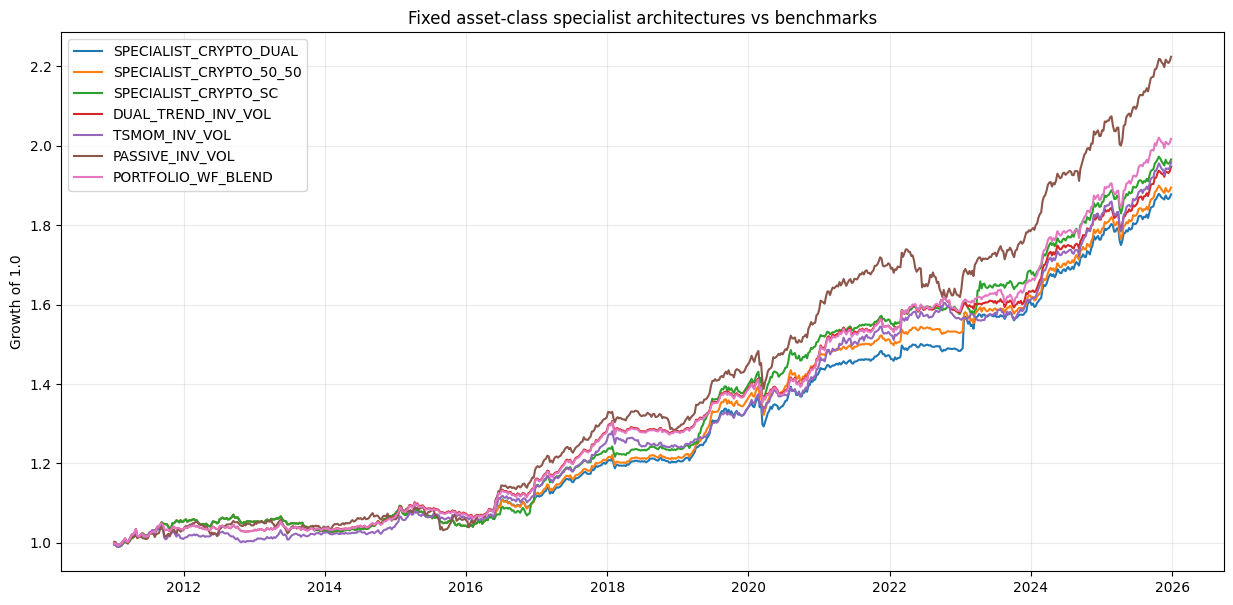

In [10]:
# ============================================================
# 13.10 — EQUITY CURVES
# ============================================================
plt.figure(figsize=(15, 7))

for name in comparison_panel.columns:
    eq = (1 + comparison_panel[name]).cumprod()
    plt.plot(eq.index, eq.values, label=name)

plt.title("Fixed asset-class specialist architectures vs benchmarks")
plt.ylabel("Growth of 1.0")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 13.11 Drawdowns


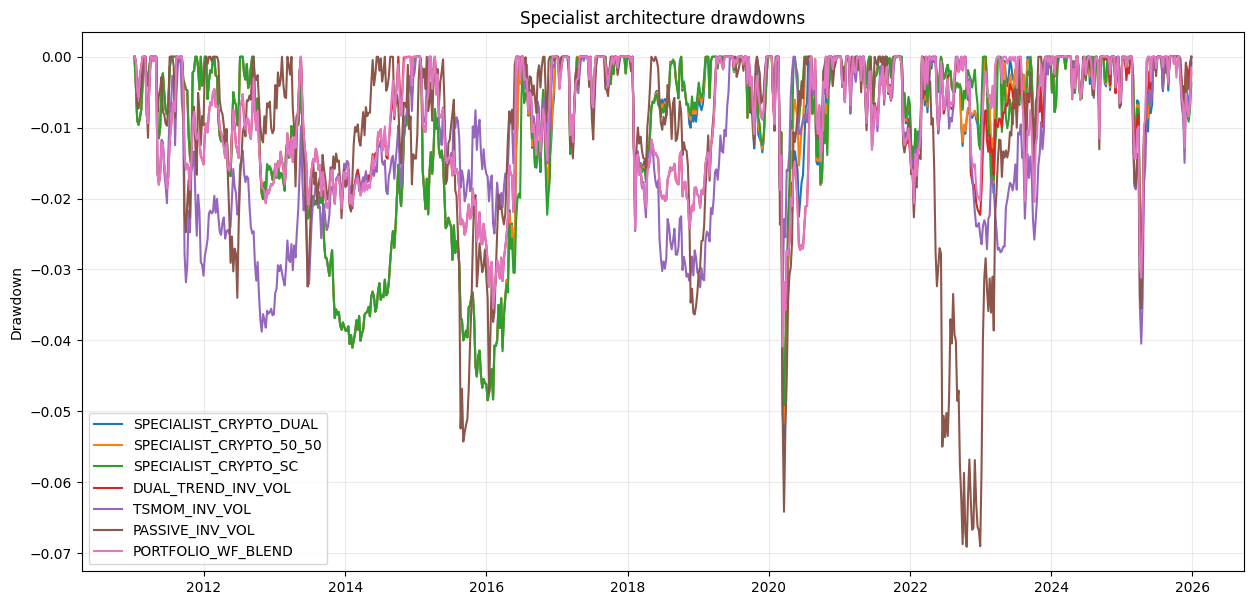

In [11]:
# ============================================================
# 13.11 — DRAWDOWNS
# ============================================================
plt.figure(figsize=(15, 7))

for name in comparison_panel.columns:
    eq = (1 + comparison_panel[name]).cumprod()
    dd = eq / eq.cummax() - 1
    plt.plot(dd.index, dd.values, label=name)

plt.title("Specialist architecture drawdowns")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 13.12 Calendar-year performance

A credible specialist architecture should not depend on one isolated recent year.


In [12]:
# ============================================================
# 13.12 — CALENDAR-YEAR RETURNS
# ============================================================
annual_rows = []

for name in comparison_panel.columns:
    r = comparison_panel[name]
    annual = (1 + r).groupby(r.index.year).prod() - 1

    for year, value in annual.items():
        annual_rows.append({
            "year": int(year),
            "strategy": name,
            "return": value,
        })

annual_returns = pd.DataFrame(annual_rows)
annual_pivot = annual_returns.pivot(
    index="year",
    columns="strategy",
    values="return",
)

display(annual_pivot)


strategy,DUAL_TREND_INV_VOL,PASSIVE_INV_VOL,PORTFOLIO_WF_BLEND,SPECIALIST_CRYPTO_50_50,SPECIALIST_CRYPTO_DUAL,SPECIALIST_CRYPTO_SC,TSMOM_INV_VOL
year,,,,,,,
2011,0.033153,0.031087,0.033153,0.053792,0.053792,0.053792,0.009898
2012,-0.002482,0.012943,-0.002482,-0.000133,-0.000133,-0.000133,-0.005631
2013,0.006092,-0.003110,0.006092,-0.022127,-0.022127,-0.022127,0.022044
2014,0.027357,0.017655,0.025333,0.039196,0.039196,0.039196,0.013105
2015,0.008969,0.001638,0.008969,-0.025856,-0.025856,-0.025856,0.023671
2016,0.081159,0.121889,0.081159,0.078283,0.070981,0.097742,0.072956
2017,0.103131,0.105837,0.103131,0.076338,0.076377,0.076031,0.101162
2018,-0.000355,-0.021380,-0.000355,0.003099,0.002296,0.003466,-0.012177
2019,0.082412,0.123695,0.082412,0.121438,0.110421,0.128148,0.077838


## 13.13 Rolling 5-year Sharpe

This reveals whether specialist architecture performance is stable across eras.


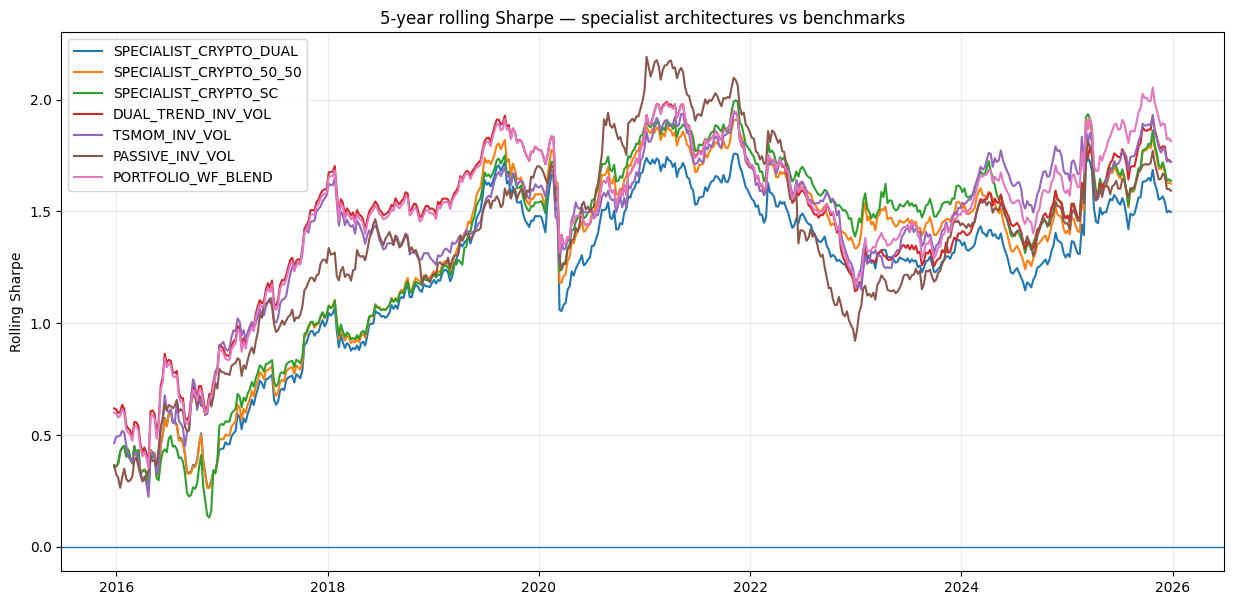

In [13]:
# ============================================================
# 13.13 — ROLLING SHARPE
# ============================================================
ROLL_WEEKS = 5 * 52

plt.figure(figsize=(15, 7))

for name in comparison_panel.columns:
    r = comparison_panel[name]
    rs = (
        r.rolling(ROLL_WEEKS).mean()
        / r.rolling(ROLL_WEEKS).std(ddof=1).replace(0, np.nan)
        * np.sqrt(WEEKS_PER_YEAR)
    )
    plt.plot(rs.index, rs.values, label=name)

plt.axhline(0, linewidth=1)
plt.title("5-year rolling Sharpe — specialist architectures vs benchmarks")
plt.ylabel("Rolling Sharpe")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 13.14 Broad subperiod stability

Use the same three coarse historical eras already used elsewhere:

- 2006–2011
- 2012–2017
- 2018–2025


In [14]:
# ============================================================
# 13.14 — SUBPERIOD PERFORMANCE
# ============================================================
SUBPERIODS = {
    "2006-2011": ("2006-01-01", "2011-12-31"),
    "2012-2017": ("2012-01-01", "2017-12-31"),
    "2018-2025": ("2018-01-01", "2025-12-31"),
}

subperiod_rows = []

for period, (start, end) in SUBPERIODS.items():
    for name in comparison_panel.columns:
        r = comparison_panel[name].loc[start:end].dropna()

        if len(r) == 0:
            continue

        subperiod_rows.append({
            "period": period,
            "strategy": name,
            **metrics(r),
        })

subperiod_performance = pd.DataFrame(subperiod_rows)
display(subperiod_performance)


,period,strategy,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
0,2006-2011,SPECIALIST_CRYPTO_DUAL,52,0.053792,0.030181,1.751660,3.055812,-0.015391,3.495141,0.013393,-0.009788,0.596154
1,2006-2011,SPECIALIST_CRYPTO_50_50,52,0.053792,0.030181,1.751660,3.055812,-0.015391,3.495141,0.013393,-0.009788,0.596154
2,2006-2011,SPECIALIST_CRYPTO_SC,52,0.053792,0.030181,1.751660,3.055812,-0.015391,3.495141,0.013393,-0.009788,0.596154
3,2006-2011,DUAL_TREND_INV_VOL,52,0.033153,0.032845,1.009452,1.269855,-0.018759,1.767319,0.008683,-0.016361,0.500000
4,2006-2011,TSMOM_INV_VOL,52,0.009898,0.043205,0.249251,0.312436,-0.031804,0.311211,0.008875,-0.019208,0.519231
5,2006-2011,PASSIVE_INV_VOL,52,0.031087,0.039087,0.802648,1.028271,-0.024745,1.256276,0.011750,-0.019343,0.576923
6,2006-2011,PORTFOLIO_WF_BLEND,52,0.033153,0.032845,1.009452,1.269855,-0.018759,1.767319,0.008683,-0.016361,0.500000
7,2012-2017,SPECIALIST_CRYPTO_DUAL,313,0.022158,0.025947,0.857752,1.341608,-0.048451,0.457327,0.014847,-0.014540,0.571885
8,2012-2017,SPECIALIST_CRYPTO_50_50,313,0.023307,0.026314,0.888847,1.414416,-0.048451,0.481031,0.015253,-0.014540,0.571885
9,2012-2017,SPECIALIST_CRYPTO_SC,313,0.026303,0.029261,0.902036,1.575936,-0.048451,0.542877,0.030425,-0.014540,0.571885


## 13.15 Stress-period performance

Use the same pre-specified stress windows as prior notebooks.


In [15]:
# ============================================================
# 13.15 — STRESS TESTS
# ============================================================
STRESS_PERIODS = {
    "Global Financial Crisis": ("2007-07-01", "2009-03-31"),
    "Euro-area stress": ("2011-05-01", "2012-07-31"),
    "COVID crash": ("2020-02-01", "2020-04-30"),
    "2022 inflation/rates shock": ("2022-01-01", "2022-12-31"),
}

stress_rows = []

for period, (start, end) in STRESS_PERIODS.items():
    for name in comparison_panel.columns:
        r = comparison_panel[name].loc[start:end].dropna()

        if len(r) == 0:
            continue

        stress_rows.append({
            "period": period,
            "strategy": name,
            "weeks": len(r),
            "total_return": (1 + r).prod() - 1,
            "max_drawdown": max_drawdown(r),
            "worst_week": r.min(),
        })

stress = pd.DataFrame(stress_rows)
display(stress)


,period,strategy,weeks,total_return,max_drawdown,worst_week
0,Euro-area stress,SPECIALIST_CRYPTO_DUAL,65,0.033929,-0.016841,-0.009788
1,Euro-area stress,SPECIALIST_CRYPTO_50_50,65,0.033929,-0.016841,-0.009788
2,Euro-area stress,SPECIALIST_CRYPTO_SC,65,0.033929,-0.016841,-0.009788
3,Euro-area stress,DUAL_TREND_INV_VOL,65,0.004813,-0.018759,-0.016361
4,Euro-area stress,TSMOM_INV_VOL,65,-0.009795,-0.031804,-0.019208
5,Euro-area stress,PASSIVE_INV_VOL,65,0.022282,-0.033990,-0.019343
6,Euro-area stress,PORTFOLIO_WF_BLEND,65,0.004813,-0.018759,-0.016361
7,COVID crash,SPECIALIST_CRYPTO_DUAL,12,0.000913,-0.054074,-0.040000
8,COVID crash,SPECIALIST_CRYPTO_50_50,12,0.005369,-0.051697,-0.038579
9,COVID crash,SPECIALIST_CRYPTO_SC,12,0.009686,-0.049144,-0.036882


## 13.16 Asset-class return contribution

For each specialist architecture, calculate a simple arithmetic attribution:

\[
Contribution_{c,t}
=
w_{c,t} r_{c,t}
\]

This identifies which asset classes contribute most to average weekly portfolio return.


In [16]:
# ============================================================
# 13.16 — ASSET-CLASS CONTRIBUTION
# ============================================================
contribution_rows = []

for name in ARCHITECTURES.keys():
    sleeves = sleeve_panels[name].reindex(comparison_panel.index)
    weights = specialist_weights[name].reindex(comparison_panel.index)

    contrib = weights * sleeves

    for asset_class in asset_classes:
        x = contrib[asset_class].dropna()

        contribution_rows.append({
            "strategy": name,
            "asset_class": asset_class,
            "mean_weekly_contribution": x.mean(),
            "annualised_mean_contribution_approx": x.mean() * WEEKS_PER_YEAR,
            "sum_contribution": x.sum(),
            "positive_contribution_week_rate": (x > 0).mean(),
        })

asset_class_contribution = pd.DataFrame(contribution_rows)
display(asset_class_contribution)


,strategy,asset_class,mean_weekly_contribution,annualised_mean_contribution_approx,sum_contribution,positive_contribution_week_rate
0,SPECIALIST_CRYPTO_DUAL,commodities,0.000114,0.005950,0.089472,0.479540
1,SPECIALIST_CRYPTO_DUAL,crypto,0.000485,0.025238,0.247527,0.500000
2,SPECIALIST_CRYPTO_DUAL,equities,0.000137,0.007140,0.107368,0.526854
3,SPECIALIST_CRYPTO_DUAL,fx,0.000161,0.008354,0.125632,0.391304
4,SPECIALIST_CRYPTO_DUAL,rates,0.000088,0.004555,0.068493,0.524297
5,SPECIALIST_CRYPTO_50_50,commodities,0.000114,0.005947,0.089429,0.479540
6,SPECIALIST_CRYPTO_50_50,crypto,0.000503,0.026168,0.256649,0.505882
7,SPECIALIST_CRYPTO_50_50,equities,0.000136,0.007062,0.106203,0.526854
8,SPECIALIST_CRYPTO_50_50,fx,0.000161,0.008382,0.126052,0.391304
9,SPECIALIST_CRYPTO_50_50,rates,0.000088,0.004566,0.068664,0.524297


## 13.17 Leave-one-asset-class-out reconstruction

Rebuild the fixed specialist architecture after excluding one asset class at a time.

This tests whether the result depends heavily on equities or crypto.


In [17]:
# ============================================================
# 13.17 — LEAVE-ONE-ASSET-CLASS-OUT
# ============================================================
def build_portfolio_from_sleeves(sleeves, excluded=None):
    cols = [c for c in sleeves.columns if c != excluded]
    s = sleeves[cols].copy()

    w = dynamic_inverse_vol_weights(s)
    r = (w * s).sum(axis=1, min_count=1)

    return r

loo_rows = []

primary_sleeves = sleeve_panels["SPECIALIST_CRYPTO_DUAL"]

for excluded in [None] + asset_classes:
    specialist_r = build_portfolio_from_sleeves(
        primary_sleeves,
        excluded=excluded
    )

    if excluded is None:
        dual_sleeves = pd.DataFrame({
            ac: ac_panel[(ac, "DUAL_TREND_13_52")]
            for ac in asset_classes
        })
    else:
        dual_sleeves = pd.DataFrame({
            ac: ac_panel[(ac, "DUAL_TREND_13_52")]
            for ac in asset_classes
            if ac != excluded
        })

    dual_r = build_portfolio_from_sleeves(dual_sleeves)

    pair = pd.concat(
        [
            specialist_r.rename("specialist"),
            dual_r.rename("dual")
        ],
        axis=1
    ).dropna()

    pair = pair.loc[:RESEARCH_END]

    loo_rows.append({
        "excluded_asset_class": excluded if excluded is not None else "NONE",
        "specialist_sharpe": sharpe(pair["specialist"]),
        "dual_sharpe": sharpe(pair["dual"]),
        "sharpe_gap": sharpe(pair["specialist"]) - sharpe(pair["dual"]),
        "specialist_cagr": cagr(pair["specialist"]),
        "dual_cagr": cagr(pair["dual"]),
        "specialist_max_drawdown": max_drawdown(pair["specialist"]),
        "dual_max_drawdown": max_drawdown(pair["dual"]),
    })

leave_one_asset_class_out = pd.DataFrame(loo_rows)
display(leave_one_asset_class_out)


,excluded_asset_class,specialist_sharpe,dual_sharpe,sharpe_gap,specialist_cagr,dual_cagr,specialist_max_drawdown,dual_max_drawdown
0,NONE,1.399020,1.362510,0.036510,0.050972,0.048142,-0.054074,-0.047596
1,commodities,1.313843,1.272992,0.040851,0.047233,0.044448,-0.059401,-0.054074
2,crypto,1.222265,1.176058,0.046207,0.038803,0.036374,-0.048451,-0.047596
3,equities,1.239638,1.239638,0.000000,0.047522,0.047522,-0.064947,-0.064947
4,fx,1.147280,1.145943,0.001336,0.058923,0.055105,-0.100290,-0.092836
5,rates,1.027990,1.153561,-0.125572,0.066086,0.063627,-0.120340,-0.097684


## 13.18 Transaction-cost / implementation-drag stress

Because the fixed specialist map itself does not switch through time, implementation complexity should be low.

Still, apply simple additional annual drag to the specialist portfolio:

- 0 bps
- 10 bps
- 25 bps
- 50 bps

This is deliberately conservative and separate from the upstream market-level costs already included in SuperbCommand.


In [18]:
# ============================================================
# 13.18 — COST STRESS
# ============================================================
COST_STRESS_BPS = [0, 10, 25, 50]

cost_rows = []

base_specialist = comparison_panel["SPECIALIST_CRYPTO_DUAL"]

for bps in COST_STRESS_BPS:
    weekly_drag = (bps / 10000) / WEEKS_PER_YEAR
    r = base_specialist - weekly_drag

    m = metrics(r)

    cost_rows.append({
        "extra_annual_drag_bps": bps,
        **m,
        "dual_sharpe_reference": dual_metrics["sharpe"],
        "sharpe_gap_vs_dual": m["sharpe"] - dual_metrics["sharpe"],
    })

cost_stress = pd.DataFrame(cost_rows)
display(cost_stress)


,extra_annual_drag_bps,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate,dual_sharpe_reference,sharpe_gap_vs_dual
0,0,782,0.042770,0.033528,1.266342,1.761683,-0.054074,0.790959,0.050805,-0.040000,0.597187,1.450324,-0.183982
1,10,782,0.041729,0.033528,1.236515,1.720883,-0.054148,0.770648,0.050786,-0.040019,0.595908,1.450324,-0.213808
2,25,782,0.040169,0.033528,1.191776,1.659279,-0.054258,0.740321,0.050757,-0.040048,0.594629,1.450324,-0.258547
3,50,782,0.037573,0.033528,1.117211,1.555464,-0.054443,0.690142,0.050709,-0.040096,0.594629,1.450324,-0.333113


## 13.19 Moving-block bootstrap versus Dual Trend

Jointly resample the primary specialist architecture and Dual Trend using 13-week moving blocks.

This tests whether the fixed specialist improvement is statistically robust.


In [19]:
# ============================================================
# 13.19 — MOVING-BLOCK BOOTSTRAP
# ============================================================
RANDOM_SEED = 20260905
BOOTSTRAP_ITERATIONS = 5000
BLOCK_WEEKS = 13

pair = comparison_panel[
    ["SPECIALIST_CRYPTO_DUAL", "DUAL_TREND_INV_VOL"]
].dropna()

arr = pair.to_numpy()
n = len(arr)

rng = np.random.default_rng(RANDOM_SEED)

def moving_block_sample(data, block_len, rng):
    nobs = len(data)
    starts = np.arange(0, nobs - block_len + 1)

    blocks = []
    total = 0

    while total < nobs:
        s = int(rng.choice(starts))
        block = data[s:s + block_len]
        blocks.append(block)
        total += len(block)

    return np.vstack(blocks)[:nobs]

boot_rows = []

for i in range(BOOTSTRAP_ITERATIONS):
    sample = moving_block_sample(arr, BLOCK_WEEKS, rng)

    sp = pd.Series(sample[:, 0])
    dt = pd.Series(sample[:, 1])

    boot_rows.append({
        "iteration": i,
        "sharpe_gap": sharpe(sp) - sharpe(dt),
        "cagr_gap": cagr(sp) - cagr(dt),
        "sortino_gap": sortino(sp) - sortino(dt),
        "max_drawdown_gap": max_drawdown(sp) - max_drawdown(dt),
    })

bootstrap = pd.DataFrame(boot_rows)

bootstrap_summary = pd.DataFrame({
    "metric": [
        "P(Specialist Sharpe > Dual)",
        "P(Specialist CAGR > Dual)",
        "P(Specialist Sortino > Dual)",
        "P(Specialist MaxDD better than Dual)",
        "Median Sharpe gap",
        "Sharpe gap 2.5%",
        "Sharpe gap 97.5%",
        "Median CAGR gap",
        "CAGR gap 2.5%",
        "CAGR gap 97.5%",
    ],
    "value": [
        (bootstrap["sharpe_gap"] > 0).mean(),
        (bootstrap["cagr_gap"] > 0).mean(),
        (bootstrap["sortino_gap"] > 0).mean(),
        (bootstrap["max_drawdown_gap"] > 0).mean(),
        bootstrap["sharpe_gap"].median(),
        bootstrap["sharpe_gap"].quantile(0.025),
        bootstrap["sharpe_gap"].quantile(0.975),
        bootstrap["cagr_gap"].median(),
        bootstrap["cagr_gap"].quantile(0.025),
        bootstrap["cagr_gap"].quantile(0.975),
    ],
})

display(bootstrap_summary)


,metric,value
0,P(Specialist Sharpe > Dual),0.116800
1,P(Specialist CAGR > Dual),0.350200
2,P(Specialist Sortino > Dual),0.214600
3,P(Specialist MaxDD better than Dual),0.140000
4,Median Sharpe gap,-0.164781
5,Sharpe gap 2.5%,-0.416539
6,Sharpe gap 97.5%,0.115865
7,Median CAGR gap,-0.002178
8,CAGR gap 2.5%,-0.012084
9,CAGR gap 97.5%,0.009681


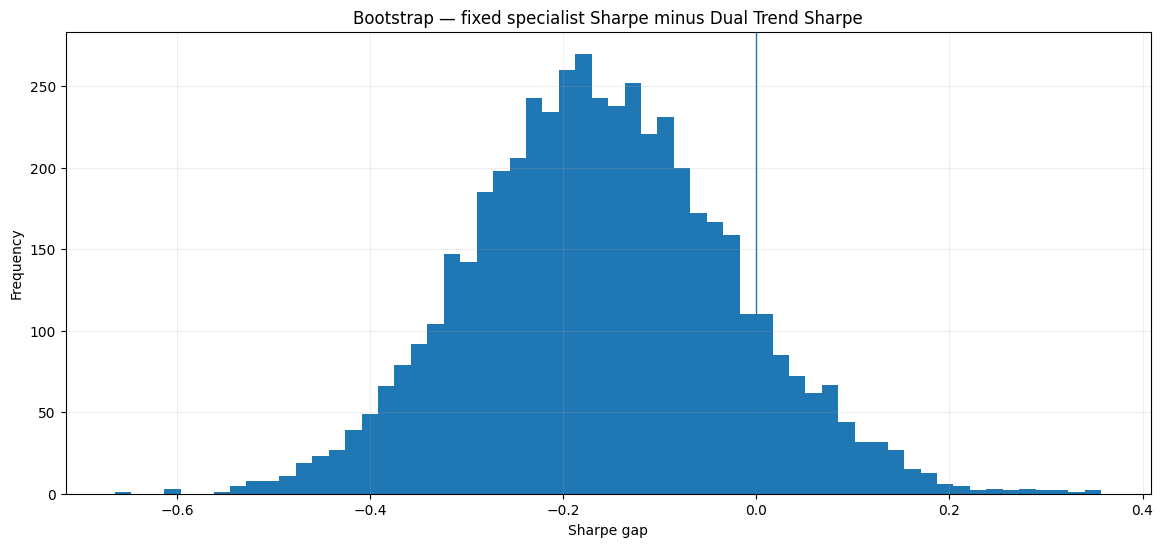

In [20]:
# ============================================================
# 13.20 — BOOTSTRAP SHARPE-GAP DISTRIBUTION
# ============================================================
plt.figure(figsize=(14, 6))
plt.hist(bootstrap["sharpe_gap"], bins=60)
plt.axvline(0, linewidth=1)
plt.title("Bootstrap — fixed specialist Sharpe minus Dual Trend Sharpe")
plt.xlabel("Sharpe gap")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.show()


## 13.21 Leave-one-year-out robustness

A fixed architecture should not owe its result to a single calendar year.


In [21]:
# ============================================================
# 13.21 — LEAVE-ONE-YEAR-OUT
# ============================================================
loo_year_rows = []

pair = comparison_panel[
    ["SPECIALIST_CRYPTO_DUAL", "DUAL_TREND_INV_VOL"]
].dropna().copy()

for year in sorted(pair.index.year.unique()):
    g = pair[pair.index.year != year]

    loo_year_rows.append({
        "excluded_year": int(year),
        "specialist_sharpe": sharpe(g["SPECIALIST_CRYPTO_DUAL"]),
        "dual_sharpe": sharpe(g["DUAL_TREND_INV_VOL"]),
        "sharpe_gap": (
            sharpe(g["SPECIALIST_CRYPTO_DUAL"])
            - sharpe(g["DUAL_TREND_INV_VOL"])
        ),
    })

leave_one_year_out = pd.DataFrame(loo_year_rows)
display(leave_one_year_out)


,excluded_year,specialist_sharpe,dual_sharpe,sharpe_gap
0,2011,1.235302,1.483099,-0.247797
1,2012,1.332200,1.526092,-0.193892
2,2013,1.373230,1.511324,-0.138094
3,2014,1.240860,1.454650,-0.213790
4,2015,1.403225,1.520176,-0.116951
5,2016,1.216478,1.400459,-0.183981
6,2017,1.181882,1.315593,-0.133710
7,2018,1.325712,1.545738,-0.220026
8,2019,1.132131,1.350261,-0.218130
9,2020,1.327047,1.518242,-0.191195


## 13.22 Parsimony scorecard

The fixed specialist architecture has only one structural deviation from Dual Trend:

> **Equities use SuperbCommand PT_REDUCE_25.**

Crypto sensitivity is reported separately and is not part of the primary frozen map unless the evidence is unusually strong.

The scorecard asks whether this one extra rule earns its complexity.


In [22]:
# ============================================================
# 13.22 — PARSIMONY SCORECARD
# ============================================================
primary_metrics = metrics(comparison_panel["SPECIALIST_CRYPTO_DUAL"])
wf_metrics = metrics(comparison_panel["PORTFOLIO_WF_BLEND"])

loo_positive_share = (
    leave_one_year_out["sharpe_gap"] > 0
).mean()

loo_ac_positive_share = (
    leave_one_asset_class_out[
        leave_one_asset_class_out["excluded_asset_class"] != "NONE"
    ]["sharpe_gap"] > 0
).mean()

scorecard = pd.DataFrame([
    {
        "test": "Observed Sharpe > Dual Trend",
        "passes": primary_metrics["sharpe"] > dual_metrics["sharpe"],
        "evidence": primary_metrics["sharpe"] - dual_metrics["sharpe"],
    },
    {
        "test": "Observed Sortino > Dual Trend",
        "passes": primary_metrics["sortino"] > dual_metrics["sortino"],
        "evidence": primary_metrics["sortino"] - dual_metrics["sortino"],
    },
    {
        "test": "Observed MaxDD no worse than Dual by >1pp",
        "passes": (
            primary_metrics["max_drawdown"]
            >= dual_metrics["max_drawdown"] - 0.01
        ),
        "evidence": (
            primary_metrics["max_drawdown"]
            - dual_metrics["max_drawdown"]
        ),
    },
    {
        "test": "Bootstrap P(Sharpe gap > 0) > 50%",
        "passes": (bootstrap["sharpe_gap"] > 0).mean() > 0.5,
        "evidence": (bootstrap["sharpe_gap"] > 0).mean(),
    },
    {
        "test": "Leave-one-year-out positive Sharpe majority",
        "passes": loo_positive_share > 0.5,
        "evidence": loo_positive_share,
    },
    {
        "test": "Leave-one-asset-class-out positive Sharpe majority",
        "passes": loo_ac_positive_share > 0.5,
        "evidence": loo_ac_positive_share,
    },
    {
        "test": "Within 0.05 Sharpe of portfolio WF blend",
        "passes": (
            wf_metrics["sharpe"] - primary_metrics["sharpe"]
        ) <= 0.05,
        "evidence": (
            primary_metrics["sharpe"] - wf_metrics["sharpe"]
        ),
    },
])

display(scorecard)

print(
    "Tests supporting fixed specialist architecture:",
    int(scorecard["passes"].sum()),
    "of",
    len(scorecard)
)


,test,passes,evidence
0,Observed Sharpe > Dual Trend,False,-0.183982
1,Observed Sortino > Dual Trend,False,-0.330908
2,Observed MaxDD no worse than Dual by >1pp,False,-0.013179
3,Bootstrap P(Sharpe gap > 0) > 50%,False,0.116800
4,Leave-one-year-out positive Sharpe majority,False,0.000000
5,Leave-one-asset-class-out positive Sharpe majo...,True,0.600000
6,Within 0.05 Sharpe of portfolio WF blend,False,-0.215973


Tests supporting fixed specialist architecture: 1 of 7


## 13.23 Research interpretation flags

Notebook 13 does not automatically declare a final architecture.

Use the following interpretation:

### Strong support

If the primary specialist architecture:

- beats Dual Trend on Sharpe and Sortino;
- survives bootstrap and leave-one-out tests;
- remains close to or better than the WF blend;
- does not materially worsen drawdown;

then the fixed specialist map becomes the leading candidate for architecture freeze.

### Mixed support

If it modestly beats Dual Trend but trails the WF blend, prefer the more parsimonious architecture unless the gap is economically meaningful.

### Weak support

If it fails to beat Dual Trend robustly, retain Dual Trend or the already-validated WF blend rather than tuning the specialist map further.


## 13.24 Save outputs


In [23]:
# ============================================================
# 13.24 — SAVE OUTPUTS
# ============================================================
PERF_PATH = PATHS["results"] / "13_specialist_performance.csv"
DELTA_PATH = PATHS["results"] / "13_specialist_deltas_vs_dual.csv"
ANNUAL_PATH = PATHS["results"] / "13_specialist_annual_returns.csv"
SUBPERIOD_PATH = PATHS["results"] / "13_specialist_subperiod_performance.csv"
STRESS_PATH = PATHS["results"] / "13_specialist_stress_summary.csv"
CONTRIB_PATH = PATHS["results"] / "13_asset_class_contribution.csv"
LOO_AC_PATH = PATHS["results"] / "13_leave_one_asset_class_out.csv"
COST_PATH = PATHS["results"] / "13_specialist_cost_stress.csv"
BOOT_PATH = PATHS["results"] / "13_specialist_bootstrap.csv"
BOOT_SUMMARY_PATH = PATHS["results"] / "13_specialist_bootstrap_summary.csv"
LOO_YEAR_PATH = PATHS["results"] / "13_specialist_leave_one_year_out.csv"
SCORECARD_PATH = PATHS["results"] / "13_specialist_scorecard.csv"
RETURNS_PATH = PATHS["data_processed"] / "13_specialist_return_panel.parquet"

performance.to_csv(PERF_PATH, index=False)
deltas_vs_dual.to_csv(DELTA_PATH, index=False)
annual_returns.to_csv(ANNUAL_PATH, index=False)
subperiod_performance.to_csv(SUBPERIOD_PATH, index=False)
stress.to_csv(STRESS_PATH, index=False)
asset_class_contribution.to_csv(CONTRIB_PATH, index=False)
leave_one_asset_class_out.to_csv(LOO_AC_PATH, index=False)
cost_stress.to_csv(COST_PATH, index=False)
bootstrap.to_csv(BOOT_PATH, index=False)
bootstrap_summary.to_csv(BOOT_SUMMARY_PATH, index=False)
leave_one_year_out.to_csv(LOO_YEAR_PATH, index=False)
scorecard.to_csv(SCORECARD_PATH, index=False)
comparison_panel.to_parquet(RETURNS_PATH)

print("Saved Notebook 13 outputs.")


Saved Notebook 13 outputs.


## 13.25 Validation suite

Notebook 13 passes only if:

- 2026 remains absent;
- the primary fixed map is exactly the predeclared map;
- no asset class other than crypto has multiple specialist treatments;
- only three crypto treatments are tested;
- inverse-vol weights are lagged;
- portfolio weights sum to one whenever available;
- bootstrap uses exactly 5,000 joint 13-week blocks;
- all outputs are written.


In [24]:
# ============================================================
# 13.25 — VALIDATION SUITE
# ============================================================
checks = {}

checks["holdout_absent"] = comparison_panel.index.max() <= RESEARCH_END
checks["2026_absent"] = not (comparison_panel.index.year == 2026).any()

checks["primary_map_exact"] = PRIMARY_MAP == {
    "commodities": "DUAL_TREND_13_52",
    "crypto": "DUAL_TREND_13_52",
    "equities": "SC_PT_REDUCE_25",
    "fx": "DUAL_TREND_13_52",
    "rates": "DUAL_TREND_13_52",
}

checks["three_crypto_treatments_only"] = len(ARCHITECTURES) == 3

noncrypto_maps = []
for name, spec in ARCHITECTURES.items():
    noncrypto_maps.append({
        k: v for k, v in spec["map"].items()
        if k != "crypto"
    })

checks["noncrypto_map_fixed"] = all(
    m == noncrypto_maps[0]
    for m in noncrypto_maps
)

weight_checks = []

for name, w in specialist_weights.items():
    sums = w.sum(axis=1).dropna()
    sums = sums[sums > 0]

    if len(sums):
        weight_checks.append(
            np.allclose(
                sums.values,
                np.ones(len(sums)),
                atol=1e-10
            )
        )

checks["weights_sum_to_one"] = all(weight_checks)

checks["bootstrap_5000"] = len(bootstrap) == 5000
checks["bootstrap_block_13"] = BLOCK_WEEKS == 13

checks["outputs_written"] = all(
    p.exists()
    for p in [
        PERF_PATH,
        DELTA_PATH,
        ANNUAL_PATH,
        SUBPERIOD_PATH,
        STRESS_PATH,
        CONTRIB_PATH,
        LOO_AC_PATH,
        COST_PATH,
        BOOT_PATH,
        BOOT_SUMMARY_PATH,
        LOO_YEAR_PATH,
        SCORECARD_PATH,
        RETURNS_PATH,
    ]
)

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

print(validation.to_string(index=False))

if not all(checks.values()):
    failed = [k for k, v in checks.items() if not v]
    raise RuntimeError(f"Notebook 13 validation failed: {failed}")

print("\n" + "=" * 78)
print("NOTEBOOK 13 STATUS: PASS")
print("=" * 78)
print("Fixed asset-class specialist architecture research completed.")
print("No arbitrary strategy maps were searched.")
print("Only the predeclared crypto sensitivity was tested.")
print("2026 final holdout: NOT ACCESSED")
print("Review whether the specialist map deserves architecture freeze.")


                       check  passed
              holdout_absent    True
                 2026_absent    True
           primary_map_exact    True
three_crypto_treatments_only    True
         noncrypto_map_fixed    True
          weights_sum_to_one    True
              bootstrap_5000    True
          bootstrap_block_13    True
             outputs_written    True

NOTEBOOK 13 STATUS: PASS
Fixed asset-class specialist architecture research completed.
No arbitrary strategy maps were searched.
Only the predeclared crypto sensitivity was tested.
2026 final holdout: NOT ACCESSED
Review whether the specialist map deserves architecture freeze.


In [25]:
# ============================================================
# 13.26 — WRITE MANIFEST
# ============================================================
manifest = {
    "notebook_id": "13",
    "notebook_name": "Asset-Class Specialist Architecture",
    "project_name": "SuperbCommand – Multi-Asset CTA Strategy",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "research_end": str(RESEARCH_END.date()),
    "holdout_start": str(HOLDOUT_START.date()),
    "holdout_accessed": False,
    "primary_specialist_map": PRIMARY_MAP,
    "crypto_treatments": [
        "Dual Trend 100%",
        "50% SC_PT_REDUCE_25 / 50% Dual Trend",
        "SC_PT_REDUCE_25 100%",
    ],
    "risk_weighting": {
        "method": "dynamic asset-class inverse volatility",
        "lookback_weeks": VOL_LOOKBACK_WEEKS,
        "signal_lag_weeks": 1,
    },
    "bootstrap": {
        "method": "moving_block_bootstrap",
        "iterations": BOOTSTRAP_ITERATIONS,
        "block_weeks": BLOCK_WEEKS,
        "joint_resampling": True,
        "random_seed": RANDOM_SEED,
    },
    "signal_hyperparameters_optimised": False,
    "arbitrary_strategy_maps_searched": False,
    "outputs": {
        "performance": str(PERF_PATH),
        "deltas_vs_dual": str(DELTA_PATH),
        "annual_returns": str(ANNUAL_PATH),
        "subperiod_performance": str(SUBPERIOD_PATH),
        "stress_summary": str(STRESS_PATH),
        "asset_class_contribution": str(CONTRIB_PATH),
        "leave_one_asset_class_out": str(LOO_AC_PATH),
        "cost_stress": str(COST_PATH),
        "bootstrap": str(BOOT_PATH),
        "bootstrap_summary": str(BOOT_SUMMARY_PATH),
        "leave_one_year_out": str(LOO_YEAR_PATH),
        "scorecard": str(SCORECARD_PATH),
        "return_panel": str(RETURNS_PATH),
    },
    "status": "PASS",
}

MANIFEST_PATH = PATHS["manifests"] / "13_asset_class_specialist_architecture_manifest.json"

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:")
print(MANIFEST_PATH)


Saved manifest:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/13_asset_class_specialist_architecture_manifest.json


---

# End of Notebook 13

## Main research question

\[
\boxed{\text{Does a fixed asset-class specialist architecture outperform pure Dual Trend without requiring a meta-selector?}}
\]

The primary hypothesis is deliberately simple:

- **Equities → SuperbCommand PT_REDUCE_25**
- **Everything else → Dual Trend 13/52**

with only a narrow predeclared crypto sensitivity.

### Why this matters

If successful, this architecture would offer a cleaner interpretation than the portfolio-level walk-forward blend:

> Conventional trend remains the macro core, while SuperbCommand is reserved for the asset class where its asymmetric accumulation / pullback logic appears most structurally appropriate.

If unsuccessful, the project should not continue tuning strategy maps. The evidence would favour either:

- pure Dual Trend; or
- the already-validated portfolio-level WF blend.

### Final holdout

**2026 remains completely untouched.**
